In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import os
file_paths=[]
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        file_paths.append(os.path.join(dirname, filename))
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/vishala28/swat-dataset-secure-water-treatment-system/merged.csv
/kaggle/input/datasets/vishala28/swat-dataset-secure-water-treatment-system/normal.csv
/kaggle/input/datasets/vishala28/swat-dataset-secure-water-treatment-system/attack.csv


In [2]:
file_paths[0]

'/kaggle/input/datasets/vishala28/swat-dataset-secure-water-treatment-system/merged.csv'

In [4]:
data = pd.read_csv(file_paths[0])
data.head()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,28/12/2015 10:00:00 AM,2.427057,522.8467,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.5988,0.000128,1,1,1,Normal
1,28/12/2015 10:00:01 AM,2.446274,522.8860,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.6789,0.000128,1,1,1,Normal
2,28/12/2015 10:00:02 AM,2.489191,522.8467,2.0,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6789,0.000128,1,1,1,Normal
3,28/12/2015 10:00:03 AM,2.534350,522.9645,2.0,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6148,0.000128,1,1,1,Normal
4,28/12/2015 10:00:04 AM,2.569260,523.4748,2.0,2,1,262.0161,8.394514,328.6337,2.443085,...,2,1,250.8812,1.649953,189.5027,0.000128,1,1,1,Normal


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441719 entries, 0 to 1441718
Data columns (total 53 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0    Timestamp     1441719 non-null  object 
 1   FIT101         1441719 non-null  float64
 2   LIT101         1441719 non-null  float64
 3    MV101         449919 non-null   float64
 4   P101           1441719 non-null  int64  
 5   P102           1441719 non-null  int64  
 6    AIT201        449919 non-null   float64
 7   AIT202         1441719 non-null  float64
 8   AIT203         1441719 non-null  float64
 9   FIT201         1441719 non-null  float64
 10   MV201         449919 non-null   float64
 11   P201          449919 non-null   float64
 12   P202          449919 non-null   float64
 13  P203           1441719 non-null  int64  
 14   P204          449919 non-null   float64
 15  P205           1441719 non-null  int64  
 16  P206           1441719 non-null  int64  
 17  DPIT301 

In [6]:
data.shape

(1441719, 53)

In [ ]:
'''
1.1 Load SWaT Dataset
The SWaT dataset contains:

Normal data: 7 days of normal operation (~496,800 records)
Attack data: 4 days including 36 attack scenarios (~449,919 records)
Sensor Types:

FIT: Flow Indicator Transmitter
LIT: Level Indicator Transmitter
AIT: Analyzer Indicator Transmitter
PIT: Pressure Indicator Transmitter
DPIT: Differential Pressure Indicator Transmitter
Actuator Types:

MV: Motorized Valve
P: Pump
UV: UV Lamp (dechlorination)
'''
 

data.isna().sum()/len(data) *100 
#MV101-> Motorized Valve at stage 1
#AIT201->Analyzer Indicators for pH
#MV201->Motorized Valve at stage 2
#P201->Pumps at stage 2
#P202->Pumps at stage 2
#P204->Pumps at stage 2
#MV303-> Motorized Valves at stage 3

In [7]:
data[data.duplicated()].shape[0]/len(data) *100 #34% of data is duplicates

34.33338951626496

In [8]:
data.drop_duplicates(inplace=True)

In [9]:
data[data.duplicated()]

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack


In [10]:
data['Normal/Attack'].unique()

array(['Normal', 'Attack'], dtype=object)

In [11]:
#convert timestap from object to datetime
#There are white spaces in the start of each date so trim it first
data[' Timestamp'] = pd.to_datetime(data[' Timestamp'].str.strip(), format='%d/%m/%Y %I:%M:%S %p')

In [11]:
#Discover the sequence of data for one day 29/12/2015
#It seems that is there are a read for every second from 12 am to 12 pm
data[data[' Timestamp'].dt.date.astype(str)=='2015-12-30']

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
128118,2015-12-30 00:00:00,0.000000,759.8549,1.0,2,1,240.6434,8.422392,337.5801,2.476276,...,2,1,249.5514,0.816967,188.1569,0.000000,1,1,1,Normal
128119,2015-12-30 00:00:01,0.000000,759.4623,1.0,2,1,240.6434,8.422392,337.5801,2.476276,...,2,1,249.5514,0.816967,188.1569,0.000000,1,1,1,Normal
128120,2015-12-30 00:00:02,0.000000,758.3240,1.0,2,1,240.6434,8.422392,337.5032,2.476276,...,2,1,249.5514,0.816967,188.1569,0.000000,1,1,1,Normal
128121,2015-12-30 00:00:03,0.000000,757.8137,1.0,2,1,240.6434,8.422392,337.5032,2.476276,...,2,1,249.5514,0.816967,188.1569,0.000000,1,1,1,Normal
128122,2015-12-30 00:00:04,0.000000,757.4212,1.0,2,1,240.6434,8.422392,337.5032,2.476276,...,2,1,249.5514,0.865024,188.3331,0.000000,1,1,1,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1398850,2015-12-30 17:28:56,2.646446,438.5711,2.0,1,1,206.5176,8.453794,326.7111,0.000384,...,2,1,244.9692,1.601897,184.2797,0.000064,1,1,1,Attack
1398851,2015-12-30 17:28:57,2.667264,439.0028,2.0,1,1,206.5176,8.456358,325.9421,0.000384,...,2,1,244.8891,1.601897,184.2797,0.000064,1,1,1,Attack
1398852,2015-12-30 17:28:58,2.668225,439.9449,2.0,1,1,206.5176,8.461805,325.4807,0.000384,...,2,1,244.7129,1.601897,184.2797,0.000064,1,1,1,Attack
1398853,2015-12-30 17:28:59,2.637799,440.9655,2.0,1,1,206.5176,8.464048,324.9167,0.000384,...,2,1,244.7129,1.601897,184.2797,0.000064,1,1,1,Attack


In [12]:
# Define sensor and actuator columns based on SWaT documentation
# SWaT has 51 sensors/actuators total [citation:2][citation:8]
sensor_cols = ['FIT101', 'LIT101', 'AIT201', 'FIT201', 'AIT202', 'AIT203',
               'FIT301', 'LIT301', 'FIT401', 'LIT401', 'AIT401', 'AIT402',
               'FIT501', 'FIT502', 'FIT503', 'FIT504', 'PIT501', 'PIT502',
               'FIT601', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'AIT505', 'AIT506']

actuator_cols = ['MV101', 'P101', 'P102', 'MV201', 'P201', 'P202', 'P203',
                 'P204', 'P205', 'P206', 'MV301', 'MV302', 'MV303', 'MV304',
                 'P301', 'P302', 'P401', 'P402', 'P403', 'P404', 'UV401',
                 'P501', 'P502', 'P601', 'P602']

In [13]:
data.set_index(' Timestamp',inplace=True) #Making the time to be the index of the dataframe

In [14]:
import numpy as np
data['Normal/Attack_label']=np.where(data['Normal/Attack']=='Normal',0,1)

In [15]:
data['Normal/Attack_label'].unique()

array([0, 1])

* Univaraite Analysis 

In [16]:
data.head()

,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack,Normal/Attack_label
Timestamp,,,,,,,,,,,,,,,,,,,,,
2015-12-28 10:00:00,2.427057,522.8467,2.0,2,1,262.0161,8.396437,328.6337,2.445391,2.0,...,1,250.8652,1.649953,189.5988,0.000128,1,1,1,Normal,0
2015-12-28 10:00:01,2.446274,522.8860,2.0,2,1,262.0161,8.396437,328.6337,2.445391,2.0,...,1,250.8652,1.649953,189.6789,0.000128,1,1,1,Normal,0
2015-12-28 10:00:02,2.489191,522.8467,2.0,2,1,262.0161,8.394514,328.6337,2.442316,2.0,...,1,250.8812,1.649953,189.6789,0.000128,1,1,1,Normal,0
2015-12-28 10:00:03,2.534350,522.9645,2.0,2,1,262.0161,8.394514,328.6337,2.442316,2.0,...,1,250.8812,1.649953,189.6148,0.000128,1,1,1,Normal,0
2015-12-28 10:00:04,2.569260,523.4748,2.0,2,1,262.0161,8.394514,328.6337,2.443085,2.0,...,1,250.8812,1.649953,189.5027,0.000128,1,1,1,Normal,0


In [17]:
data.isna().sum()

FIT101                      0
LIT101                      0
 MV101                 496809
P101                        0
P102                        0
 AIT201                496809
AIT202                      0
AIT203                      0
FIT201                      0
 MV201                 496809
 P201                  496809
 P202                  496809
P203                        0
 P204                  496809
P205                        0
P206                        0
DPIT301                     0
FIT301                      0
LIT301                      0
MV301                       0
MV302                       0
 MV303                 496809
MV304                       0
P301                        0
P302                        0
AIT401                      0
AIT402                      0
FIT401                      0
LIT401                      0
P401                        0
P402                        0
P403                        0
P404                        0
UV401     

In [18]:
Columns_in_null=data.columns[data.isna().any()].tolist()
Columns_in_null
#Getting the columns names that has null values to discover if that null value has a specific meaning

[' MV101', ' AIT201', ' MV201', ' P201', ' P202', ' P204', ' MV303']

In [ ]:
'''
2. Specific Reasons for Each Column's Null Values
MV101 (Motorized Valve)
Reason: This valve is only active when the raw water tank level (LIT101) drops below a certain threshold 

When null: Tank is full or water intake is not required

AIT201 (Conductivity Sensor)
Reason: Only measures when water flows through Stage P2

When null: No water flow from P1 to P2 (P201/P202 inactive)

MV201 (Motorized Valve)
Reason: Dependent on multiple upstream components: P101, P102, and P203 activity 

When null: Either P1 pumps are off OR chemical dosing (P203) is inactive

P201, P202, P204 (Pumps)
Reason: These pumps operate in cycles based on chemical dosing requirements

When null: No water in Stage P2 to process, or system in standby mode

MV303 (Motorized Valve)
Reason: Controls feed flow to the ultrafiltration (UF) membranes in Stage P3

When null: P3 is inactive OR upstream flow from Stage P2 is stopped
'''

* Analyze Null Patterns in Normal vs Attack Periods 

In [ ]:
def analyze_null_patterns(df, columns, is_attack_data=False):
    """
    Analyze null patterns across specified columns
    """
    results = {}
    
    for col in columns:
        if col in df.columns:
            # Calculate null percentage
            null_pct = df[col].isnull().mean() * 100
            
            # Get null periods (continuous blocks)
            null_mask = df[col].isnull().astype(int)#Convert null to zeros
            null_blocks = (null_mask.diff() == 1).sum()  # Number of null blocks
            
            # Get max consecutive nulls
            max_consecutive = null_mask.groupby((null_mask != null_mask.shift()).cumsum()).sum().max()
            
            results[col] = {
                'null_percentage': null_pct,
                'null_blocks': null_blocks,
                'max_consecutive_nulls': max_consecutive
            }
    
    return pd.DataFrame(results).T

# Compare normal training data vs test data
print("\n🔍 NULL PATTERN ANALYSIS")
print("="*60)

normal_null_analysis = analyze_null_patterns(train_df, columns_with_nulls)
test_null_analysis = analyze_null_patterns(test_df, columns_with_nulls)

print("\n📈 Null Patterns in NORMAL Operation (Training Data):")
print(normal_null_analysis)

print("\n📈 Null Patterns in TEST Data (Contains Attacks):")
print(test_null_analysis)

# Identify suspicious columns (where null patterns changed significantly)
print("\n⚠️ SUSPICIOUS COLUMNS (Significant Null Pattern Changes):")
print("="*50)

for col in columns_with_nulls:
    if col in normal_null_analysis.index and col in test_null_analysis.index:
        normal_pct = normal_null_analysis.loc[col, 'null_percentage']
        test_pct = test_null_analysis.loc[col, 'null_percentage']
        change = test_pct - normal_pct
        
        if abs(change) > 10:  # More than 10% change
            if change > 0:
                print(f"🔴 {col}: Nulls INCREASED by {change:.1f}% (New nulls appearing during attacks)")
            else:
                print(f"🟢 {col}: Nulls DECREASED by {abs(change):.1f}% (Components active when normally idle)")

In [ ]:
# For each column with nulls, check the dependency pattern
dependency_pairs = {
    'MV101': ['LIT101'],           # MV101 depends on water level
    'MV201': ['P101', 'P102'],      # MV201 depends on P1 pumps
    'P201': ['MV201'],              # P201 depends on valve state
    'P202': ['P201'],               # P202 is backup
    'MV303': ['MV201', 'P201']      # MV303 depends on upstream flow
}
#Analyzes whether a null value in a specific column at a specific time is expected (normal) 
#or suspicious (potential attack)
#column: The component name you're checking (like 'MV101')
#timestamp: The specific time you want to analyze
def analyze_null_reason(df, column, timestamp):
    
    """Determine if null is expected or suspicious"""
    row = df.loc[timestamp] #Retrieves the entire row of data for that specific timestamp
    
    if column in dependency_pairs:
        for dep in dependency_pairs[column]:
            if dep in row.index and pd.notna(row[dep]):
                # Dependency active but this column null → SUSPICIOUS
                if row[dep] == 2:  # 2 = active in SWaT
                    return "⚠️ SUSPICIOUS: Active upstream but null"
    
    return "✅ EXPECTED: Upstream inactive"

In [57]:
(data[' MV201'].isnull().astype(int)).diff()==1

 Timestamp
2015-12-28 10:00:00    False
2015-12-28 10:00:01    False
2015-12-28 10:00:02    False
2015-12-28 10:00:03    False
2015-12-28 10:00:04    False
                       ...  
2016-01-02 13:41:07    False
2016-01-02 13:41:08    False
2016-01-02 13:41:09    False
2016-01-02 13:41:10    False
2016-01-02 13:41:11    False
Name:  MV201, Length: 946728, dtype: bool

In [75]:
#For each feature, visualize its behavior across attack periods.
#This helps identify which specific sensors show anomalous patterns during each attack.
#The fuction is designed to analyze how a single sensor or actuator behaves
#during an attack by comparing it with normal operation.
def plot_univariate_attack_impact(feature_name, attack_start, attack_end, window_minutes=30):
    """
    Plot a single sensor/actuator behavior before, during, and after an attack
    """
    # Get attack period from test data
    data_contains_attacks=data[data['Normal/Attack']=='Attack'].copy()
    #Contains the data when attack starts and when it ends
    #Takes a slice of the data which contains attacks during the specified time window
    attack_data = data_contains_attacks.loc[attack_start:attack_end].copy() 
    
    
    # Get normal baseline (same time window from normal operation)
    '''
    Tries to find data from 7 days earlier (same time, different day)

    If that exact time doesn't exist, it takes the last N rows from training data
    (where N = length of attack period)
    
    '''
    data_contains_attacks=data[data['Normal/Attack']=='Normal'].copy()
    normal_start = attack_start - pd.Timedelta(days=7)  # Previous week
    normal_end = attack_end - pd.Timedelta(days=7)
    normal_data = data_contains_attacks.loc[normal_start:normal_end].copy() if normal_start in data_contains_attacks.index else data_contains_attacks.iloc[-len(attack_data):]
    
    # Create visualization
    fig, axes = plt.subplots(3, 1, figsize=(15, 10))
    #Creates a figure with 3 vertical subplots sharing the same width (15 inches wide, 10 inches tall
    # Plot 1: Normal operation baseline
    #How the sensor/actuator behaves during normal operation
    axes[0].plot(normal_data.index, normal_data[feature_name], color='green', alpha=0.7)
    axes[0].set_title(f'{feature_name} - Normal Operation (Baseline)', fontsize=12)
    axes[0].set_ylabel('Value')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Attack period with attack phases highlighted
    '''
    Red dots: Moments when attack is active (Attack_Label = 1)

    Blue dots: Normal moments within the test window

    Red shaded area: The entire attack window

    Purpose: See exactly how behavior changes during attack
    
    
    '''
    colors = ['blue' if label==0 else 'red' for label in attack_data['Normal/Attack_label']]
    axes[1].scatter(attack_data.index, attack_data[feature_name], c=colors, s=5, alpha=0.7)
    axes[1].axvspan(attack_start, attack_end, alpha=0.2, color='red', label='Attack Window')
    axes[1].set_title(f'{feature_name} - During Attack', fontsize=12)
    axes[1].set_ylabel('Value')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    
    
    # Plot 3: Statistical comparison
    normal_stats = normal_data[feature_name].describe()
    attack_stats = attack_data[feature_name].describe()
    
    stats_df = pd.DataFrame({
        'Normal': [normal_stats['mean'], normal_stats['std'], normal_stats['min'], normal_stats['max']],
        'Attack': [attack_stats['mean'], attack_stats['std'], attack_stats['min'], attack_stats['max']]
    }, index=['Mean', 'Std Dev', 'Min', 'Max'])
    
    stats_df.plot(kind='bar', ax=axes[2], color=['green', 'red'])
    axes[2].set_title(f'{feature_name} - Statistical Comparison', fontsize=12)
    axes[2].set_ylabel('Value')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()
    
    plt.suptitle(f'Attack Impact Analysis on {feature_name}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print anomaly detection metrics
    print(f"\n📊 Anomaly Detection Metrics for {feature_name}:")
    print(f"Normal Range: [{normal_stats['min']:.2f}, {normal_stats['max']:.2f}]")
    print(f"Attack Range: [{attack_stats['min']:.2f}, {attack_stats['max']:.2f}]")
    print(f"Deviation Magnitude: {abs(attack_stats['mean'] - normal_stats['mean']):.2f}")
    
    return normal_stats, attack_stats

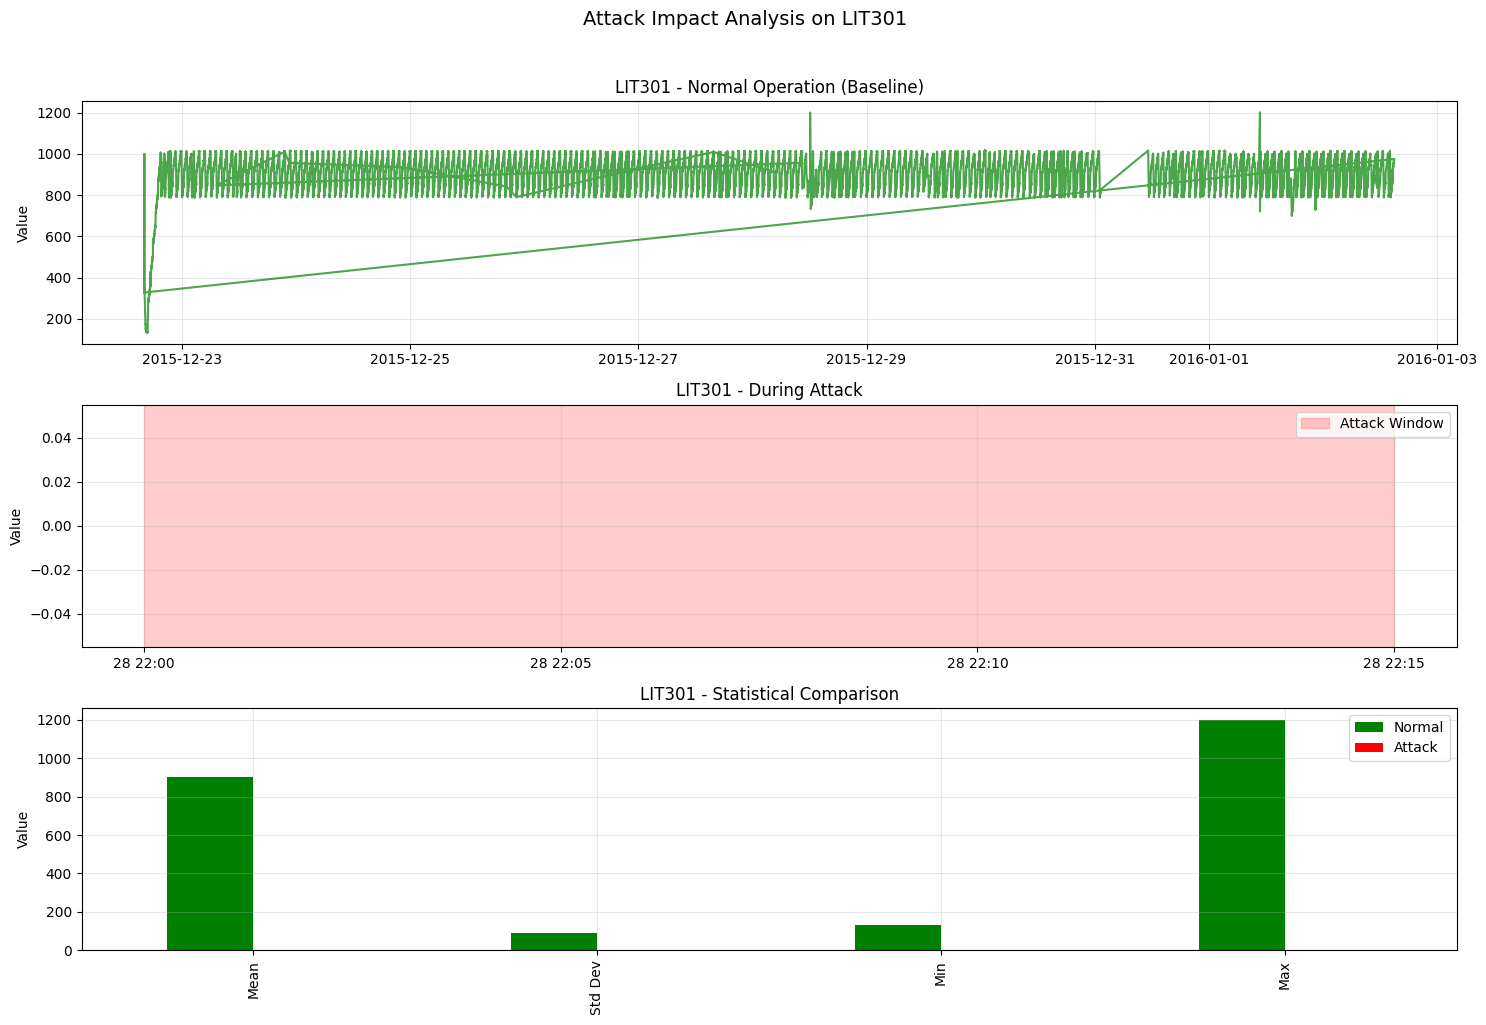


📊 Anomaly Detection Metrics for LIT301:
Normal Range: [132.82, 1201.00]
Attack Range: [nan, nan]
Deviation Magnitude: nan


In [76]:
# Define attack #5 timing (from the table above)
from datetime import datetime
attack_start =datetime.strptime('2015-12-28 22:00:00', '%Y-%m-%d %H:%M:%S')
attack_end =datetime.strptime('2015-12-28 22:15:00', '%Y-%m-%d %H:%M:%S')


# Analyze LIT301
normal_stats, attack_stats = plot_univariate_attack_impact(
    feature_name='LIT301',
    attack_start=attack_start,
    attack_end=attack_end,
    window_minutes=30
)

In [19]:
from datetime import datetime

# Your string
date_string = '2015-12-28 22:15:00'

# Convert to datetime object
timestamp = datetime.strptime(date_string, '%Y-%m-%d %H:%M:%S')

print(timestamp)
print(type(timestamp))

2015-12-28 22:15:00
<class 'datetime.datetime'>


In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 946728 entries, 2015-12-28 10:00:00 to 2016-01-02 13:41:11
Data columns (total 53 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   FIT101               946728 non-null  float64
 1   LIT101               946728 non-null  float64
 2    MV101               449919 non-null  float64
 3   P101                 946728 non-null  int64  
 4   P102                 946728 non-null  int64  
 5    AIT201              449919 non-null  float64
 6   AIT202               946728 non-null  float64
 7   AIT203               946728 non-null  float64
 8   FIT201               946728 non-null  float64
 9    MV201               449919 non-null  float64
 10   P201                449919 non-null  float64
 11   P202                449919 non-null  float64
 12  P203                 946728 non-null  int64  
 13   P204                449919 non-null  float64
 14  P205                 946728 non-nu

In [21]:
data[data['Normal/Attack']=='Attack'].index

DatetimeIndex(['2015-12-28 10:29:14', '2015-12-28 10:29:15',
               '2015-12-28 10:29:16', '2015-12-28 10:29:17',
               '2015-12-28 10:29:18', '2015-12-28 10:29:19',
               '2015-12-28 10:29:20', '2015-12-28 10:29:21',
               '2015-12-28 10:29:22', '2015-12-28 10:29:23',
               ...
               '2016-01-02 13:41:02', '2016-01-02 13:41:03',
               '2016-01-02 13:41:04', '2016-01-02 13:41:05',
               '2016-01-02 13:41:06', '2016-01-02 13:41:07',
               '2016-01-02 13:41:08', '2016-01-02 13:41:09',
               '2016-01-02 13:41:10', '2016-01-02 13:41:11'],
              dtype='datetime64[ns]', name=' Timestamp', length=54621, freq=None)

In [22]:
# Remove startup period (first 4.5 hours = 16200 seconds) 
data_Stable=data.iloc[16200:]

* Hadling Missing values

In [23]:
data_Stable.fillna(method='ffill', inplace=True) #Use forward fill most common in time series
#We don't use backward fill as it will make data lekage
# For any remaning at the begining use Backward fill
data_Stable.fillna(method='bfill', inplace=True)
#Linear interpolation
#df.interpolate(method='linear', inplace=True)
#use interpolation and see the effect of it on the accuracy

/tmp/ipykernel_55/326655033.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_Stable.fillna(method='ffill', inplace=True) #Use forward fill most common in time series
/tmp/ipykernel_55/326655033.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_Stable.fillna(method='ffill', inplace=True) #Use forward fill most common in time series
/tmp/ipykernel_55/326655033.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_Stable.fillna(method='bfill', inplace=True)
/tmp/ipykernel_55/326655033.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the doc

In [24]:
data_Stable.isnull().sum().sum() #The Missing values were handled

np.int64(0)

* Feature engineering

In [25]:
#Add time-based features to capture temporal patterns
# Extract time features from index
data_Stable['hour'] = data_Stable.index.hour
data_Stable['minute'] = data_Stable.index.minute
data_Stable['dayofweek'] = data_Stable.index.dayofweek
    
# Sin/cos encoding for cyclical features
data_Stable['hour_sin'] = np.sin(2 * np.pi * data_Stable['hour'] / 24)
data_Stable['hour_cos'] = np.cos(2 * np.pi * data_Stable['hour'] / 24)
    
data_Stable['minute']['minute_sin'] = np.sin(2 * np.pi * data_Stable['minute'] / 60)
data_Stable['minute']['minute_cos'] = np.cos(2 * np.pi * data_Stable['minute'] / 60)
    
# Day of week (7-day cycle)

data_Stable['day_sin'] = np.sin(2 * np.pi * data_Stable['dayofweek'] / 7)
data_Stable['day_cos'] = np.cos(2 * np.pi * data_Stable['dayofweek'] / 7)

/tmp/ipykernel_55/3716608715.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_Stable['hour'] = data_Stable.index.hour
/tmp/ipykernel_55/3716608715.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_Stable['minute'] = data_Stable.index.minute
/tmp/ipykernel_55/3716608715.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

In [26]:
Label=data_Stable['Normal/Attack_label']
Label

 Timestamp
2015-12-28 15:44:26    0
2015-12-28 15:44:27    0
2015-12-28 15:44:28    0
2015-12-28 15:44:29    0
2015-12-28 15:44:30    0
                      ..
2016-01-02 13:41:07    1
2016-01-02 13:41:08    1
2016-01-02 13:41:09    1
2016-01-02 13:41:10    1
2016-01-02 13:41:11    1
Name: Normal/Attack_label, Length: 930528, dtype: int64

In [27]:
df=data_Stable.copy()
df=df.drop(['Normal/Attack_label','Normal/Attack'] , axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 930528 entries, 2015-12-28 15:44:26 to 2016-01-02 13:41:11
Data columns (total 58 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   FIT101     930528 non-null  float64
 1   LIT101     930528 non-null  float64
 2    MV101     930528 non-null  float64
 3   P101       930528 non-null  int64  
 4   P102       930528 non-null  int64  
 5    AIT201    930528 non-null  float64
 6   AIT202     930528 non-null  float64
 7   AIT203     930528 non-null  float64
 8   FIT201     930528 non-null  float64
 9    MV201     930528 non-null  float64
 10   P201      930528 non-null  float64
 11   P202      930528 non-null  float64
 12  P203       930528 non-null  int64  
 13   P204      930528 non-null  float64
 14  P205       930528 non-null  int64  
 15  P206       930528 non-null  int64  
 16  DPIT301    930528 non-null  float64
 17  FIT301     930528 non-null  float64
 18  LIT301     930528 non-null  fl

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    df, Label, test_size=0.30, random_state=42)

In [29]:
#Use different scaling and normalizations
#Scale features using training data statistics only to prevent data leakage
def scale_data(train_data, test_data,scaler_type='standard'):
   
    print(f"\n Scaling data using {scaler_type}...")
    
    if scaler_type == 'standard':
        scaler = StandardScaler()
    elif scaler_type == 'minmax':
        scaler = MinMaxScaler()
    else:
        raise ValueError("scaler_type must be 'standard' or 'minmax'")
    
    # Fit on training data only
    scaler.fit(X_train)
    
    # Transform both training and test data
    train_scaled = scaler.transform(X_train)
    test_scaled = scaler.transform(X_test)
    
    # Convert back to DataFrames
    train_scaled_df = pd.DataFrame(train_scaled,columns=train_data.columns, index=train_data.index)
    test_scaled_df = pd.DataFrame(test_scaled, columns=test_data.columns, index=test_data.index)
    
    
    return train_scaled_df, test_scaled_df, scaler

# Scale the data (use time features or original features)
train_scaled, test_scaled, scaler = scale_data(
    X_train, X_test,  scaler_type='minmax'
)

test_scaled.head()


 Scaling data using minmax...


,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,P601,P602,P603,hour,minute,dayofweek,hour_sin,hour_cos,day_sin,day_cos
Timestamp,,,,,,,,,,,,,,,,,,,,,
2015-12-29 12:10:03,0.945579,0.424428,1.0,1.0,0.0,0.934748,0.809453,0.167909,0.868444,1.0,...,0.0,0.0,0.0,0.521739,0.169492,0.166667,0.500000,0.000000,0.900969,0.801938
2015-12-23 21:14:38,0.946623,0.453488,1.0,1.0,0.0,0.000643,0.783075,0.171089,0.865089,1.0,...,0.0,0.0,0.0,0.913043,0.237288,0.333333,0.146447,0.853553,1.000000,0.356896
2015-12-23 16:14:44,0.906591,0.431035,1.0,1.0,0.0,0.000643,0.784790,0.165364,0.863276,1.0,...,0.0,0.0,0.0,0.695652,0.237288,0.333333,0.066987,0.250000,1.000000,0.356896
2015-12-26 12:03:33,0.935484,0.469335,1.0,1.0,0.0,0.000643,0.788007,0.149827,0.868172,1.0,...,0.0,0.0,0.0,0.521739,0.050847,0.833333,0.500000,0.000000,0.000000,0.356896
2015-12-27 15:26:01,0.940009,0.452729,1.0,1.0,0.0,0.000643,0.787578,0.153189,0.863095,1.0,...,0.0,0.0,0.0,0.652174,0.440678,1.000000,0.146447,0.146447,0.099031,0.801938


In [30]:
# ============================================
# PCA (Principal Component Analysis)
# ============================================
from sklearn.decomposition import PCA
def apply_pca(X_train, X_test, n_components=None, variance_threshold=0.95):#will preserve with the the data of 95% variance 
    """
    Apply PCA for dimensionality reduction
    """
    print("\n" + "="*60)
    print("🔵 PCA DIMENSIONALITY REDUCTION")
    print("="*60)
    
    # Determine number of components
    if n_components is None:
        # Find components that explain variance_threshold of variance
        pca_temp = PCA()
        pca_temp.fit(X_train)
        cumsum = np.cumsum(pca_temp.explained_variance_ratio_)
        n_components = np.argmax(cumsum >= variance_threshold) + 1
        print(f"📊 {n_components} components explain {variance_threshold:.1%} of variance")
    
    # Apply PCA
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    # Explained variance
    explained_var = pca.explained_variance_ratio_
    cumsum_var = np.cumsum(explained_var)
    
    print(f"\n📈 Explained variance by component:")
    for i, var in enumerate(explained_var[:10]):
        print(f"  PC{i+1}: {var:.4f} (cumulative: {cumsum_var[i]:.4f})")
    
    print(f"\n✅ PCA reduced dimensions from {X_train.shape[1]} to {X_train_pca.shape[1]}")
    
    return X_train_pca, X_test_pca, pca

# Apply PCA (keep 95% variance)
X_train_pca, X_test_pca, pca_model = apply_pca(train_scaled, test_scaled, variance_threshold=0.95)




🔵 PCA DIMENSIONALITY REDUCTION
📊 13 components explain 95.0% of variance

📈 Explained variance by component:
  PC1: 0.3258 (cumulative: 0.3258)
  PC2: 0.1241 (cumulative: 0.4499)
  PC3: 0.1075 (cumulative: 0.5573)
  PC4: 0.0804 (cumulative: 0.6378)
  PC5: 0.0717 (cumulative: 0.7095)
  PC6: 0.0593 (cumulative: 0.7688)
  PC7: 0.0434 (cumulative: 0.8122)
  PC8: 0.0391 (cumulative: 0.8514)
  PC9: 0.0371 (cumulative: 0.8885)
  PC10: 0.0276 (cumulative: 0.9161)

✅ PCA reduced dimensions from 58 to 13


* Implement One SVM

In [ ]:
def apply_one_class_svm(X_train, X_test, y_true=None, nu=0.05, gamma='auto'):
    """
    Apply One-Class SVM for anomaly detection
    nu: upper bound on fraction of training errors and lower bound on fraction of support vectors
    gamma: kernel coefficient ('auto', 'scale', or float)
    """
    print("\n" + "="*60)
    print("🔵 ONE-CLASS SVM DETECTION")
    print("="*60)
    
    # Initialize and train One-Class SVM
    ocsvm = OneClassSVM(nu=nu, gamma=gamma, kernel='rbf')
    
    print(f"Training One-Class SVM with nu={nu}, gamma={gamma}...")
    ocsvm.fit(X_train)
    
    # Predict on test data
    # Returns: +1 for inliers (normal), -1 for outliers (anomalies)
    y_pred_raw = ocsvm.predict(X_test)
    
    # Convert to binary: 0 for normal, 1 for anomaly
    y_pred = (y_pred_raw == -1).astype(int)
    
    # Calculate anomaly scores (distance from decision boundary)
    # For One-Class SVM, we can use decision_function
    scores = -ocsvm.decision_function(X_test)  # Higher score = more anomalous
    
    # Evaluate if ground truth is available
    if y_true is not None:
        # Calculate metrics
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
        
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        
        try:
            auc = roc_auc_score(y_true, scores)
        except:
            auc = None
        
        print(f"\n📊 One-Class SVM Results:")
        print(f"  Accuracy:  {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        if auc:
            print(f"  AUC-ROC:   {auc:.4f}")
        
        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        print(f"\n  Confusion Matrix:")
        print(f"  TN: {cm[0,0]:,} | FP: {cm[0,1]:,}")
        print(f"  FN: {cm[1,0]:,} | TP: {cm[1,1]:,}")
        
        return ocsvm, y_pred, scores, {'accuracy': accuracy, 'precision': precision, 
                                       'recall': recall, 'f1': f1, 'auc': auc}
    else:
        return ocsvm, y_pred, scores, None

# Apply One-Class SVM
ocsvm_model, ocsvm_pred, ocsvm_scores, ocsvm_metrics = apply_one_class_svm(
    X_train_pca, X_test_pca, y_test, nu=0.05, gamma='auto'
)
ocsvm_model


🔵 ONE-CLASS SVM DETECTION
Training One-Class SVM with nu=0.05, gamma=auto...


In [30]:
ocsvm_metrics

{'accuracy': 0.9127808883109626,
 'precision': 0.21846943138093203,
 'recall': 0.18642831083546152,
 'f1': 0.2011811023622047,
 'auc': np.float64(0.7934124801327103)}

* Use another way to enhance the model

In [35]:
data_try=data_Stable.copy()
data_try.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 930528 entries, 2015-12-28 15:44:26 to 2016-01-02 13:41:11
Data columns (total 60 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   FIT101               930528 non-null  float64
 1   LIT101               930528 non-null  float64
 2    MV101               930528 non-null  float64
 3   P101                 930528 non-null  int64  
 4   P102                 930528 non-null  int64  
 5    AIT201              930528 non-null  float64
 6   AIT202               930528 non-null  float64
 7   AIT203               930528 non-null  float64
 8   FIT201               930528 non-null  float64
 9    MV201               930528 non-null  float64
 10   P201                930528 non-null  float64
 11   P202                930528 non-null  float64
 12  P203                 930528 non-null  int64  
 13   P204                930528 non-null  float64
 14  P205                 930528 non-nu

In [37]:
'''
data_try = data_try.interpolate(method='linear', limit_direction='both')  
# أي قيم متبقية NaN نملأها بـ ffill
data_try.fillna(method='ffill', inplace=True)
data_try.fillna(method='bfill', inplace=True)
data_try.fillna(method='ffill', inplace=True)
data_try.fillna(method='bfill', inplace=True)
'''

/tmp/ipykernel_55/309251603.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_try = data_try.interpolate(method='linear', limit_direction='both')
/tmp/ipykernel_55/309251603.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_try.fillna(method='ffill', inplace=True)
/tmp/ipykernel_55/309251603.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_try.fillna(method='bfill', inplace=True)
/tmp/ipykernel_55/309251603.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_try.fillna(method='ffill', inplace=True)
/tmp/ipykernel_55/309251603.py:6: FutureWarning: DataFrame.fillna w

In [41]:
train_try_scaled, test_try_scaled, scaler = scale_data(
    X_train, X_test,  scaler_type='standard'
)


 Scaling data using standard...


In [42]:
X_train_pca, X_test_pca, pca_model = apply_pca(train_scaled, test_scaled, variance_threshold=0.95)



🔵 PCA DIMENSIONALITY REDUCTION
📊 23 components explain 95.0% of variance

📈 Explained variance by component:
  PC1: 0.3007 (cumulative: 0.3007)
  PC2: 0.0973 (cumulative: 0.3981)
  PC3: 0.0629 (cumulative: 0.4609)
  PC4: 0.0590 (cumulative: 0.5199)
  PC5: 0.0570 (cumulative: 0.5770)
  PC6: 0.0401 (cumulative: 0.6171)
  PC7: 0.0383 (cumulative: 0.6554)
  PC8: 0.0362 (cumulative: 0.6916)
  PC9: 0.0305 (cumulative: 0.7221)
  PC10: 0.0274 (cumulative: 0.7495)

✅ PCA reduced dimensions from 58 to 23


In [ ]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(train_df[feature_cols])
X_test_scaled = scaler.transform(test_df[feature_cols])

* Apply k-means

In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
def apply_kmeans_reduced_fixed(X_train, X_test, y_true=None, n_clusters=30, threshold_percentile=95):
    """Apply K-Means detection with proper shape handling"""
    
    print("\n" + "="*60)
    print("🟢 K-MEANS on PCA-reduced Data")
    print("="*60)
    print(f"X_train: {X_train.shape}")
    print(f"X_test: {X_test.shape}")
    
    # Fix shape mismatch
    if y_true is not None and X_test.shape[0] != len(y_true):
        print(f"⚠️ Shape mismatch: X_test={X_test.shape[0]}, y_true={len(y_true)}")
        min_len = min(X_test.shape[0], len(y_true))
        X_test = X_test[:min_len]
        y_true = y_true[:min_len]
        print(f"✅ Truncated to {min_len} samples")
    
    # Train K-Means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(X_train)
    
    # Calculate distances and threshold
    train_distances = kmeans.transform(X_train).min(axis=1)
    threshold = np.percentile(train_distances, threshold_percentile)
    print(f"Distance threshold: {threshold:.4f}")
    
    # Predict on test data
    test_distances = kmeans.transform(X_test).min(axis=1)
    y_pred = (test_distances > threshold).astype(int)
    scores = test_distances
    
    # Evaluate if labels available
    if y_true is not None:
        f1 = f1_score(y_true, y_pred)
        try:
            auc = roc_auc_score(y_true, scores)
        except:
            auc = None
        
        print(f"\n📊 Results:")
        print(f"  F1-Score:  {f1:.4f}")
        if auc:
            print(f"  AUC-ROC:   {auc:.4f}")
        
        cm = confusion_matrix(y_true, y_pred)
        print(f"\n  Confusion Matrix:")
        print(f"  TN: {cm[0,0]:,} | FP: {cm[0,1]:,}")
        print(f"  FN: {cm[1,0]:,} | TP: {cm[1,1]:,}")
        
        return kmeans, y_pred, scores, {'f1': f1, 'auc': auc}
    
    return kmeans, y_pred, scores, None

# Apply K-Means
kmeans_pca, kmeans_pca_pred, kmeans_pca_scores, kmeans_pca_metrics = apply_kmeans_reduced_fixed(
    X_train_pca, X_test_pca, y_test, n_clusters=30, threshold_percentile=95
)


🟢 K-MEANS on PCA-reduced Data
X_train: (837475, 23)
X_test: (93053, 23)
Distance threshold: 4.7816

📊 Results:
  F1-Score:  0.1449
  AUC-ROC:   0.3726

  Confusion Matrix:
  TN: 83,578 | FP: 3,993
  FN: 4,742 | TP: 740
